In [1]:
# Install recommended transformers version and other dependencies
%pip install --upgrade pandas unsloth transformers==4.56.0 peft bitsandbytes accelerate safetensors trl datasets matplotlib sacrebleu

  Using cached trl-0.29.0-py3-none-any.whl.metadata (11 kB)
  Using cached datasets-4.7.0-py3-none-any.whl.metadata (19 kB)
  Using cached trl-0.24.0-py3-none-any.whl.metadata (11 kB)
INFO: pip is looking at multiple versions of trl to determine which version is compatible with other requirements. This could take a while.
  Using cached trl-0.23.1-py3-none-any.whl.metadata (11 kB)
  Using cached trl-0.23.0-py3-none-any.whl.metadata (11 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
from unsloth import is_bfloat16_supported, FastLanguageModel
import os
import re
import unicodedata
from contextlib import nullcontext
from dataclasses import dataclass
from typing import List

import pandas as pd
import torch
from datasets import Dataset, load_dataset
from peft import AutoPeftModelForCausalLM
import sacrebleu
from tqdm.auto import tqdm
from trl import SFTConfig, SFTTrainer
from transformers import AutoTokenizer, EarlyStoppingCallback

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
# Load competition data
train_ds = pd.read_csv(
    "../../competitions/deep-past-initiative-machine-translation/train.csv"
)
test_ds = pd.read_csv(
    "../../competitions/deep-past-initiative-machine-translation/test.csv"
)

# Load additional labeled data with a local fallback for no-internet Kaggle runs
if os.path.exists("merged_train.csv"):
    hf_ds = pd.read_csv("merged_train.csv")
else:
    hf_ds = load_dataset("phucthaiv02/akkadian-translation", split="train").to_pandas()  # type: ignore
hf_ds = hf_ds[["translation", "transliteration"]].copy()

published_ds = pd.read_csv(
    "../../competitions/deep-past-initiative-machine-translation/published_texts.csv"
)
published_ds = published_ds.rename(columns={"AICC_translation": "translation"})
published_ds = published_ds[["translation", "transliteration"]].copy()
published_ds = published_ds.dropna(subset=["translation", "transliteration"])

competition_pairs = train_ds[["translation", "transliteration"]].copy()
competition_pairs["source"] = "competition_train"
hf_ds["source"] = "hf_extra"
published_ds["source"] = "published_texts"

competition_pairs = competition_pairs.dropna(subset=["translation", "transliteration"])
hf_ds = hf_ds.dropna(subset=["translation", "transliteration"])
published_ds = published_ds.dropna(subset=["translation", "transliteration"])

# Keep a true in-domain validation slice from the competition train set
val_size = min(
    len(competition_pairs), max(200, int(len(competition_pairs) * 0.08)), 1000
)
val_indices = competition_pairs.sample(n=val_size, random_state=0).index
val_full_ds = competition_pairs.loc[val_indices].reset_index(drop=True)
competition_train_ds = competition_pairs.drop(index=val_indices).reset_index(drop=True)

# Train on the remaining competition data plus external/public labeled pairs
train_full_ds = pd.concat(
    [competition_train_ds, hf_ds, published_ds],
    ignore_index=True,
)

print(f"Competition train total: {len(competition_pairs)}")
print(f"Held-out validation size: {len(val_full_ds)}")
print(f"Training dataset size before normalization: {len(train_full_ds)}")

train_full_ds.to_csv("merged_train.csv", index=False)
train_full_ds.head()

Competition train total: 1561
Held-out validation size: 200
Training dataset size before normalization: 99842


,translation,transliteration,source
0,"Seal of Mannum-balum-Aššur son of Ṣilli-Adad, ...",KIŠIB ma-nu-ba-lúm-a-šur DUMU ṣí-lá-{d}IM KIŠI...,competition_train
1,Itūr-ilī has received one textile of ordinary ...,1 TÚG ša qá-tim i-tur₄-DINGIR il₅-qé,competition_train
2,<gap> he did not give you a textile. He return...,TÚG u-la i-dí-na-ku-um i-tù-ra-ma 9 GÍN KÙ.BABBAR,competition_train
3,"Seal of Šu-Illil son of Šu-Kūbum, seal of Ṣilū...",KIŠIB šu-{d}EN.LÍL DUMU šu-ku-bi-im KIŠIB ṣí-l...,competition_train
4,"From Šu-Tammuzī, Elaya, Ennam-Aššur and Lamass...",um-ma šu-ta-mu-zi e-lá-a en-um-a-šùr ù lá-ma-s...,competition_train


In [4]:
DETERMINATIVE_MAP = {
    "d": " deity ",
    "mul": " constellation ",
    "ki": " place ",
    "lu2": " person ",
    "lu": " person ",
    "e2": " temple ",
    "uru": " city ",
    "kur": " land ",
    "mi": " woman ",
    "m": " man ",
    "gesh": " wood ",
    "geš": " wood ",
    "tug2": " cloth ",
    "dub": " tablet ",
    "id2": " river ",
    "musen": " bird ",
    "na4": " stone ",
    "kusz": " leather ",
    "kuš": " leather ",
    "u2": " plant ",
}


def _normalize_subscripts(text: str) -> str:
    text = unicodedata.normalize("NFKC", text)
    return text.translate(str.maketrans("₀₁₂₃₄₅₆₇₈₉ₓ", "0123456789x"))


def _clean_determinatives(text: str) -> str:
    def repl(match):
        raw = _normalize_subscripts(match.group(1).lower()).replace(".", "").strip()
        return DETERMINATIVE_MAP.get(raw, f" {raw} ")

    return re.sub(r"\{([^{}]+)\}", repl, text)


def normalize_transliteration(text):
    if not isinstance(text, str):
        return ""

    text = _normalize_subscripts(text)
    text = text.replace("Ḫ", "H").replace("ḫ", "h")
    text = text.replace("sz", "š").replace("s,", "ṣ").replace("t,", "ṭ")
    text = text.replace("g,", "ĝ")
    text = text.replace("á", "a2").replace("à", "a3")
    text = text.replace("é", "e2").replace("è", "e3")
    text = text.replace("í", "i2").replace("ì", "i3")
    text = text.replace("ú", "u2").replace("ù", "u3")
    text = text.replace("…", " <big_gap> ")
    text = re.sub(r"\[(?:\s*\.\s*){2,}\]", " <big_gap> ", text)
    text = re.sub(r"\[(?:x|X)\]", " <gap> ", text)
    text = re.sub(r"\b[xX]\b", " <gap> ", text)
    text = _clean_determinatives(text)
    text = re.sub(r"<<([^<>]+)>>", r" \1 ", text)
    text = re.sub(r"<([^<>]+)>", r" \1 ", text)
    text = re.sub(r"[˹˺\[\]]", " ", text)
    text = re.sub(r"\(([^()]*)\)", r" \1 ", text)
    text = text.replace("/", " ")
    text = text.replace(":", " ")
    text = text.replace("!", " ").replace("?", " ")
    text = re.sub(r"\.\s*", "-", text)
    text = re.sub(r"\s*[-]\s*", "-", text)
    text = re.sub(r"-{2,}", "-", text)
    text = re.sub(r"\s*<gap>\s*", " <gap> ", text)
    text = re.sub(r"\s*<big_gap>\s*", " <big_gap> ", text)
    text = re.sub(r"(?:<gap>\s+){2,}", "<big_gap> ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def normalize_translation(text):
    if not isinstance(text, str):
        return ""

    text = unicodedata.normalize("NFKC", text)
    text = text.replace("…", " <big_gap> ")
    text = re.sub(r"\[(?:\s*\.\s*){2,}\]", " <big_gap> ", text)
    text = re.sub(r"\[(?:x|X)\]", " <gap> ", text)
    text = re.sub(r"\(([^()]*)\)", r" \1 ", text)
    text = re.sub(r"<<([^<>]+)>>", r" \1 ", text)
    text = re.sub(r"<([^<>]+)>", r" \1 ", text)
    text = re.sub(r"[\[\]˹˺]", " ", text)
    text = text.replace("/", " ")
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Apply normalization guided by the competition formatting notes
train_full_ds["transliteration"] = train_full_ds["transliteration"].apply(
    normalize_transliteration
)
val_full_ds["transliteration"] = val_full_ds["transliteration"].apply(
    normalize_transliteration
)
test_ds["transliteration"] = test_ds["transliteration"].apply(normalize_transliteration)

train_full_ds["translation"] = train_full_ds["translation"].apply(normalize_translation)
val_full_ds["translation"] = val_full_ds["translation"].apply(normalize_translation)

# Deduplicate after normalization
train_full_ds = train_full_ds.drop_duplicates(
    subset=["translation", "transliteration"]
).reset_index(drop=True)
val_full_ds = val_full_ds.drop_duplicates(
    subset=["translation", "transliteration"]
).reset_index(drop=True)

Max lengths after normalization:
Max train input length: 3902
Max train target length: 4841
Max validation input length: 2942
Max validation target length: 971


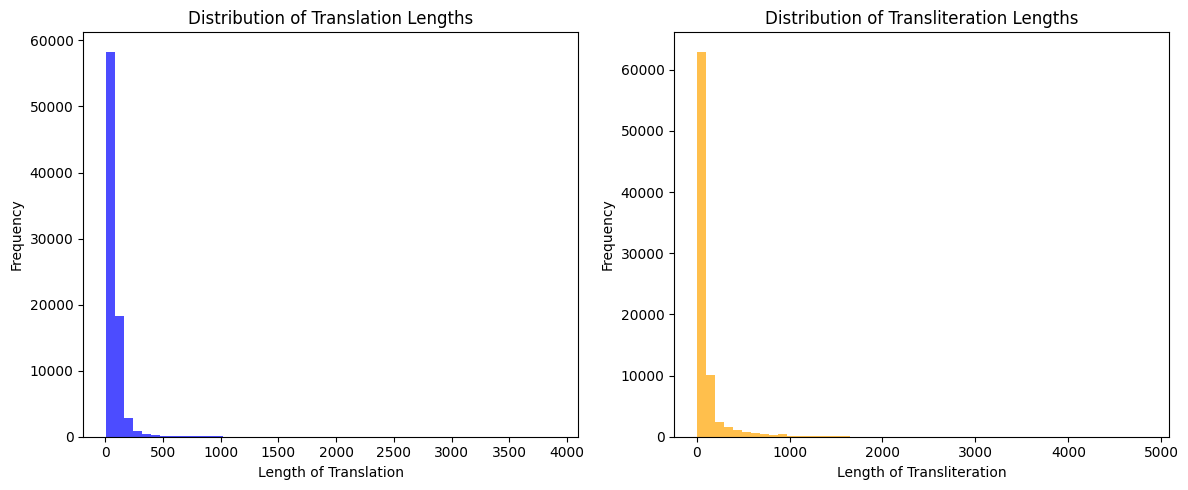

In [5]:
# Max Lengths for model input and output
print("Max lengths after normalization:")

max_train_input_length = max(train_full_ds["translation"].apply(lambda x: len(x)))
max_train_target_length = max(train_full_ds["transliteration"].apply(lambda x: len(x)))

print(f"Max train input length: {max_train_input_length}")
print(f"Max train target length: {max_train_target_length}")

max_val_input_length = max(val_full_ds["translation"].apply(lambda x: len(x)))
max_val_target_length = max(val_full_ds["transliteration"].apply(lambda x: len(x)))

print(f"Max validation input length: {max_val_input_length}")
print(f"Max validation target length: {max_val_target_length}")

import matplotlib.pyplot as plt

# Plot histograms of input and target lengths
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(
    train_full_ds["translation"].apply(lambda x: len(x)),
    bins=50,
    color="blue",
    alpha=0.7,
)
plt.title("Distribution of Translation Lengths")
plt.xlabel("Length of Translation")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(
    train_full_ds["transliteration"].apply(lambda x: len(x)),
    bins=50,
    color="orange",
    alpha=0.7,
)
plt.title("Distribution of Transliteration Lengths")
plt.xlabel("Length of Transliteration")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [6]:
train_full_ds["input_len"] = train_full_ds["transliteration"].str.len()
train_full_ds["target_len"] = train_full_ds["translation"].str.len()
val_full_ds["input_len"] = val_full_ds["transliteration"].str.len()
val_full_ds["target_len"] = val_full_ds["translation"].str.len()

max_input_length = int(train_full_ds["input_len"].quantile(0.995))
max_target_length = int(train_full_ds["target_len"].quantile(0.995))

train_full_ds = train_full_ds[
    (train_full_ds["input_len"] <= max_input_length)
    & (train_full_ds["target_len"] <= max_target_length)
]
val_full_ds = val_full_ds[
    (val_full_ds["input_len"] <= max_input_length * 1.15)
    & (val_full_ds["target_len"] <= max_target_length * 1.15)
]

train_full_ds = train_full_ds.drop(columns=["input_len", "target_len"]).reset_index(
    drop=True
)
val_full_ds = val_full_ds.drop(columns=["input_len", "target_len"]).reset_index(
    drop=True
)

print(f"Using max_input_length={max_input_length}")
print(f"Using max_target_length={max_target_length}")
print(f"Final training size: {len(train_full_ds)}")
print(f"Final validation size: {len(val_full_ds)}")
train_full_ds.to_csv("merged_train_normalized.csv", index=False)
train_full_ds.head()

Using max_input_length=1206
Using max_target_length=637
Final training size: 80719
Final validation size: 169


,translation,transliteration,source
0,"Seal of Mannum-balum-Aššur son of Ṣilli-Adad, ...",KIŠIB ma-nu-ba-lu2m-a-šur DUMU ṣi2-la2-deity I...,competition_train
1,Itūr-ilī has received one textile of ordinary ...,1 TÚG ša qa2-tim i-tur4-DINGIR il5-qe2,competition_train
2,gap he did not give you a textile. He returned...,TÚG u-la i-di2-na-ku-um i-tu3-ra-ma 9 GÍN KÙ-B...,competition_train
3,"Seal of Šu-Illil son of Šu-Kūbum, seal of Ṣilū...",KIŠIB šu-deity EN-LÍL DUMU šu-ku-bi-im KIŠIB ṣ...,competition_train
4,"Seal of Ali-ahum, seal of Ali-ilī, seal of Abi...",KIŠIB a-la2-hi-im KIŠIB a-li-li KIŠIB a-bi4-la...,competition_train


In [ ]:
# Using Tencent's Hunyuan-MT-1.8B through Unsloth
model_name = "tencent/Hunyuan-MT-7B"

max_seq_length = min(2048, max_input_length + max_target_length + 128)
dtype = torch.bfloat16 if is_bfloat16_supported() else torch.float16

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_name,
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=True,
    full_finetuning=False,
    trust_remote_code=True,
)

r = 32
model = FastLanguageModel.get_peft_model(
    model,
    r=r,
    task_type="CAUSAL_LM",
    target_modules="all-linear",
    lora_alpha=r * 2,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=0,
)


def build_training_example(example):
    user_prompt = (
        "Translate the following Old Assyrian/Akkadian transliteration into a single fluent English sentence.\n"
        "Rules:\n"
        "- Preserve proper names and place names.\n"
        "- Keep <gap> and <big_gap> verbatim when they appear.\n"
        "- Do not add commentary or multiple alternatives.\n\n"
        f"Transliteration:\n{example['transliteration']}"
    )
    messages = [
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": example["translation"]},
    ]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )
    return {
        "messages": messages,
        "text": text,
    }


train_dataset = Dataset.from_pandas(
    train_full_ds[["transliteration", "translation"]], preserve_index=False
)
val_dataset = Dataset.from_pandas(
    val_full_ds[["transliteration", "translation"]], preserve_index=False
)

map_proc = max(1, (os.cpu_count() or 2) // 2)
train_dataset = train_dataset.map(build_training_example, num_proc=map_proc)
val_dataset = val_dataset.map(build_training_example, num_proc=map_proc)

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.0)
    ],
    args=SFTConfig(
        output_dir="outputs",
        dataset_text_field="text",
        max_seq_length=max_seq_length,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        warmup_ratio=0.05,
        learning_rate=5e-5,
        num_train_epochs=2,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=10,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        seed=0,
        report_to="none",
        eval_strategy="steps",
        eval_steps=200,
        save_strategy="steps",
        save_steps=200,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        dataset_num_proc=map_proc,
        packing=False,
        assistant_only_loss=True,
        group_by_length=True,
    ),
)

trainer_stats = trainer.train()

Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.3.4: Fast Hunyuan_V1_Dense patching. Transformers: 4.56.0.
   \\   /|    NVIDIA A100 80GB PCIe. Num GPUs = 1. Max memory: 79.254 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Unsloth: Making `model.base_model.model.model` require gradients


Map (num_proc=16):   0%|          | 0/80719 [00:00<?, ? examples/s]

Map (num_proc=16):   0%|          | 0/169 [00:00<?, ? examples/s]

...

Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/169 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
import json
import shutil
from pathlib import Path

# Create a model checkpoint directory
model_dir = Path("hunyuan_mt_lora_model_final")
model_dir.mkdir(exist_ok=True)

# 1. Save the trained PEFT model and tokenizer
print("Saving PEFT model and tokenizer...")
model.save_pretrained(str(model_dir))
tokenizer.save_pretrained(str(model_dir))
print(f"✓ Model and tokenizer saved to {model_dir}")

# 2. Save training statistics
print("\nSaving training statistics...")
training_stats = {
    "model_name": model_name,
    "training_dataset_size": len(train_full_ds),
    "validation_dataset_size": len(val_full_ds),
    "max_seq_length": max_seq_length,
    "lora_r": r,
    "lora_alpha": r * 2,
    "learning_rate": trainer.args.learning_rate,
    "batch_size": trainer.args.per_device_train_batch_size,
    "gradient_accumulation_steps": trainer.args.gradient_accumulation_steps,
    "num_train_epochs": trainer.args.num_train_epochs,
    "total_training_steps": trainer.state.global_step,
}

# Save to JSON
with open(model_dir / "training_config.json", "w") as f:
    json.dump(training_stats, f, indent=2)
print(f"✓ Training config saved to {model_dir}/training_config.json")

# 3. Save training metrics if available
if hasattr(trainer, "state") and hasattr(trainer.state, "log_history"):
    metrics_df = pd.DataFrame(trainer.state.log_history)
    metrics_csv = model_dir / "training_metrics.csv"
    metrics_df.to_csv(metrics_csv, index=False)
    print(f"✓ Training metrics saved to {metrics_csv}")

# 4. Copy training output directory to model directory
if os.path.exists("outputs"):
    shutil.copytree("outputs", str(model_dir / "checkpoints"), dirs_exist_ok=True)
    print(f"✓ Checkpoints copied to {model_dir}/checkpoints")

# 5. Create a summary file
summary_text = f"""# Hunyuan-MT Akkadian-to-English Translation Model - Final Checkpoint

## Model Information
- **Base Model**: {model_name}
- **Fine-tuning Method**: LoRA (r={r}, alpha={r*2})
- **Framework**: Unsloth + Transformers + TRL

## Dataset Statistics
- **Training Samples**: {len(train_full_ds):,}
- **Validation Samples**: {len(val_full_ds):,}
- **Input Length Limit**: {max_input_length} characters
- **Target Length Limit**: {max_target_length} characters

## Training Configuration
- **Learning Rate**: 2e-5
- **Batch Size**: 8 (per device)
- **Gradient Accumulation Steps**: 4
- **Effective Batch Size**: 32
- **Max Sequence Length**: {max_seq_length}
- **Optimizer**: adamw_8bit
- **LR Scheduler**: cosine
- **Total Training Steps**: {trainer.state.global_step}

## Model Structure
The model uses LoRA adapters applied to all linear layers for efficient fine-tuning.
To use this model:

```python
from unsloth import FastLanguageModel
from peft import AutoPeftModelForCausalLM, AutoPeftModelForSeq2SeqLM

# Load the PEFT model
model = AutoPeftModelForCausalLM.from_pretrained(
    "hunyuan_mt_lora_model_final",
    load_in_4bit=True,
)
tokenizer = AutoTokenizer.from_pretrained("hunyuan_mt_lora_model_final")

# For inference
from unsloth import FastLanguageModel
FastLanguageModel.for_inference(model)
```

## Inference Example

```python
messages = [
    {{
        "role": "user",
        "content": "Translate the following segment into English, without additional explanation.\\n\\n[YOUR_AKKADIAN_TEXT_HERE]",
    }},
]

inputs = tokenizer.apply_chat_template(
    messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
).to("cuda")

outputs = model.generate(
    input_ids=inputs,
    max_new_tokens=256,
    use_cache=True,
    top_k=20,
    top_p=0.6,
    temperature=0.7,
    do_sample=True,
)

translation = tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)
```

## Files in This Directory
- `adapter_config.json`: LoRA configuration
- `adapter_model.safetensors`: LoRA weights
- `config.json`: Model configuration
- `generation_config.json`: Generation default parameters
- `tokenizer.json`: Tokenizer
- `tokenizer_config.json`: Tokenizer configuration
- `training_config.json`: Training hyperparameters
- `training_metrics.csv`: Training and validation loss per step
- `checkpoints/`: All intermediate checkpoints from training

## Training Notes
- The model was trained using the Unsloth library for efficient LoRA fine-tuning
- BF16 (bfloat16) precision was used on A100 GPU for memory efficiency
- Packing was enabled to speed up training
- Sequence length includes both instruction and completion tokens
"""

summary_path = model_dir / "README.md"
with open(summary_path, "w") as f:
    f.write(summary_text)
print(f"✓ Summary saved to {summary_path}")

# 6. Verify saved files
print("\n" + "=" * 60)
print("FINAL MODEL CHECKPOINT SAVED")
print("=" * 60)
print(f"Location: {model_dir.resolve()}")
print(f"\nTotal training steps completed: {trainer.state.global_step}")
print(f"Model size: {sum(p.numel() for p in model.parameters()):,} parameters")

# List all files in the model directory
print("\nSaved files:")
for file_path in sorted(model_dir.glob("**/*")):
    if file_path.is_file():
        file_size = file_path.stat().st_size / (1024 * 1024)  # Convert to MB
        print(f"  - {file_path.relative_to(model_dir)} ({file_size:.2f} MB)")

print("\n✓ All training artifacts saved successfully!")

In [ ]:
def _cuda_bf16_supported() -> bool:
    if not torch.cuda.is_available():
        return False
    try:
        return bool(torch.cuda.is_bf16_supported())
    except Exception:
        return False


def _bf16_autocast_ctx():
    if torch.cuda.is_available() and _cuda_bf16_supported():
        return torch.autocast(device_type="cuda", dtype=torch.bfloat16)
    return nullcontext()


def clean_prediction(text: str) -> str:
    text = normalize_translation(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def competition_score(predictions, references):
    bleu = sacrebleu.corpus_bleu(predictions, [references]).score
    chrfpp = sacrebleu.corpus_chrf(predictions, [references], word_order=2).score
    return {
        "bleu": bleu,
        "chrfpp": chrfpp,
        "geom": (max(bleu, 0.0) * max(chrfpp, 0.0)) ** 0.5,
    }


def build_retrieval_corpus(pairs_df: pd.DataFrame) -> pd.DataFrame:
    retrieval_df = pairs_df[["transliteration", "translation"]].copy()
    retrieval_df = retrieval_df.dropna(
        subset=["transliteration", "translation"]
    ).drop_duplicates()
    retrieval_df["translit_norm"] = retrieval_df["transliteration"].apply(
        normalize_transliteration
    )
    retrieval_df["translation"] = retrieval_df["translation"].apply(
        normalize_translation
    )
    retrieval_df = retrieval_df[
        retrieval_df["translit_norm"].str.len() > 0
    ].reset_index(drop=True)
    retrieval_df["token_set"] = retrieval_df["translit_norm"].str.split().apply(set)
    return retrieval_df


retrieval_corpus = build_retrieval_corpus(train_full_ds)


def retrieve_examples(transliteration: str, top_k: int = 2, min_score: float = 0.18):
    query_norm = normalize_transliteration(transliteration)
    query_tokens = set(query_norm.split())
    if not query_tokens:
        return []

    scored = retrieval_corpus.assign(
        overlap=retrieval_corpus["token_set"].apply(
            lambda token_set: len(query_tokens & token_set)
            / max(1, len(query_tokens | token_set))
        )
    )
    scored = scored[
        (scored["overlap"] >= min_score) & (scored["translit_norm"] != query_norm)
    ]
    if scored.empty:
        return []

    return scored.nlargest(top_k, "overlap")[
        ["transliteration", "translation"]
    ].to_dict("records")


def build_inference_prompt(transliteration: str, retrieved_examples=None) -> str:
    prompt_lines = [
        "Translate the following Old Assyrian/Akkadian transliteration into a single fluent English sentence.",
        "Rules:",
        "- Preserve proper names and place names.",
        "- Keep <gap> and <big_gap> verbatim when they appear.",
        "- Do not add commentary or alternatives.",
    ]

    if retrieved_examples:
        prompt_lines.append("Helpful translation examples:")
        for idx, example in enumerate(retrieved_examples, start=1):
            prompt_lines.append(
                f"Example {idx} transliteration: {example['transliteration']}"
            )
            prompt_lines.append(f"Example {idx} translation: {example['translation']}")

    prompt_lines.extend(["", "Transliteration:", transliteration])
    return "\n".join(prompt_lines)


def _deduplicate_keep_order(items):
    seen = set()
    output = []
    for item in items:
        normalized = clean_prediction(str(item))
        if normalized and normalized not in seen:
            seen.add(normalized)
            output.append(normalized)
    return output


_mbr_metric = sacrebleu.metrics.CHRF(word_order=2)


def _mbr_select(candidates):
    candidates = _deduplicate_keep_order(candidates)
    if not candidates:
        return ""
    if len(candidates) == 1:
        return candidates[0]

    best_candidate = candidates[0]
    best_score = float("-inf")
    for idx, candidate in enumerate(candidates):
        score = 0.0
        for jdx, other in enumerate(candidates):
            if idx == jdx:
                continue
            score += _mbr_metric.sentence_score(candidate, [other]).score
        score /= max(1, len(candidates) - 1)
        if score > best_score:
            best_score = score
            best_candidate = candidate
    return best_candidate


def generate_translation(
    transliteration: str,
    config: dict,
    model=model,
    tokenizer=tokenizer,
) -> str:
    retrieved_examples = retrieve_examples(
        transliteration,
        top_k=config.get("retrieval_top_k", 0),
        min_score=config.get("retrieval_min_score", 0.18),
    )
    prompt = build_inference_prompt(
        transliteration, retrieved_examples=retrieved_examples
    )
    messages = [{"role": "user", "content": prompt}]

    input_ids = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
    ).to(model.device)

    candidates = []
    generation_common = {
        "max_new_tokens": config.get("max_new_tokens", 220),
        "repetition_penalty": config.get("repetition_penalty", 1.1),
        "use_cache": True,
        "eos_token_id": tokenizer.eos_token_id,
        "pad_token_id": tokenizer.eos_token_id,
    }

    with torch.no_grad():
        with _bf16_autocast_ctx():
            beam_candidates = int(config.get("beam_candidates", 0))
            if beam_candidates > 0:
                beam_outputs = model.generate(
                    input_ids=input_ids,
                    do_sample=False,
                    num_beams=max(int(config.get("num_beams", 4)), beam_candidates),
                    num_return_sequences=beam_candidates,
                    length_penalty=float(config.get("length_penalty", 1.0)),
                    **generation_common,
                )
                for sequence in beam_outputs:
                    candidates.append(
                        tokenizer.decode(
                            sequence[input_ids.shape[1] :], skip_special_tokens=True
                        )
                    )

            sample_candidates = int(config.get("sample_candidates", 0))
            if sample_candidates > 0:
                sample_outputs = model.generate(
                    input_ids=input_ids,
                    do_sample=True,
                    num_beams=1,
                    top_p=float(config.get("top_p", 0.9)),
                    temperature=float(config.get("temperature", 0.7)),
                    num_return_sequences=sample_candidates,
                    **generation_common,
                )
                for sequence in sample_outputs:
                    candidates.append(
                        tokenizer.decode(
                            sequence[input_ids.shape[1] :], skip_special_tokens=True
                        )
                    )

    if not candidates:
        return ""

    return _mbr_select(candidates)


FastLanguageModel.for_inference(model)

tuning_subset = val_full_ds.sample(
    n=min(64, len(val_full_ds)), random_state=0
).reset_index(drop=True)
decode_grid = [
    {
        "name": "beam_only",
        "num_beams": 5,
        "beam_candidates": 4,
        "sample_candidates": 0,
        "length_penalty": 1.0,
        "retrieval_top_k": 0,
    },
    {
        "name": "mbr_no_retrieval",
        "num_beams": 6,
        "beam_candidates": 4,
        "sample_candidates": 3,
        "top_p": 0.9,
        "temperature": 0.75,
        "length_penalty": 1.0,
        "retrieval_top_k": 0,
    },
    {
        "name": "mbr_with_retrieval",
        "num_beams": 6,
        "beam_candidates": 4,
        "sample_candidates": 3,
        "top_p": 0.92,
        "temperature": 0.7,
        "length_penalty": 1.0,
        "retrieval_top_k": 2,
        "retrieval_min_score": 0.16,
    },
]

tuning_rows = []
for decode_config in decode_grid:
    preds = [
        generate_translation(transliteration, decode_config)
        for transliteration in tqdm(
            tuning_subset["transliteration"], desc=decode_config["name"]
        )
    ]
    metrics = competition_score(preds, tuning_subset["translation"].tolist())
    tuning_rows.append({**decode_config, **metrics})

tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values("geom", ascending=False)
    .reset_index(drop=True)
)
best_inference_config = tuning_results.iloc[0].to_dict()
tuning_results

In [ ]:
test_ds = pd.read_csv(
    "../../competitions/deep-past-initiative-machine-translation/test.csv"
)

# Path to trained LoRA model
model_path = "hunyuan_mt_lora_model_final"

print("Loading trained model from checkpoint...")
model = AutoPeftModelForCausalLM.from_pretrained(
    model_path,
    device_map="auto",
    load_in_4bit=True,
)
tokenizer = AutoTokenizer.from_pretrained(model_path)
model.eval()

print("Model loaded successfully!")

if os.path.exists("merged_train.csv"):
    local_extra_pairs = pd.read_csv("merged_train.csv")[
        ["translation", "transliteration"]
    ]
else:
    local_extra_pairs = pd.DataFrame(columns=["translation", "transliteration"])

competition_pairs = pd.read_csv(
    "../../competitions/deep-past-initiative-machine-translation/train.csv"
)[["translation", "transliteration"]]
published_pairs = pd.read_csv(
    "../../competitions/deep-past-initiative-machine-translation/published_texts.csv"
).rename(columns={"AICC_translation": "translation"})[
    ["translation", "transliteration"]
]

retrieval_pairs = (
    pd.concat(
        [competition_pairs, local_extra_pairs, published_pairs],
        ignore_index=True,
    )
    .dropna(subset=["translation", "transliteration"])
    .drop_duplicates()
)
retrieval_corpus = build_retrieval_corpus(retrieval_pairs)

active_inference_config = {
    "num_beams": 6,
    "beam_candidates": 4,
    "sample_candidates": 3,
    "top_p": 0.92,
    "temperature": 0.7,
    "length_penalty": 1.0,
    "retrieval_top_k": 2,
    "retrieval_min_score": 0.16,
    "max_new_tokens": 220,
    "repetition_penalty": 1.1,
}
if "best_inference_config" in globals():
    for key in active_inference_config:
        if key in best_inference_config and pd.notna(best_inference_config[key]):
            active_inference_config[key] = best_inference_config[key]

for int_key in [
    "num_beams",
    "beam_candidates",
    "sample_candidates",
    "retrieval_top_k",
    "max_new_tokens",
]:
    active_inference_config[int_key] = int(active_inference_config[int_key])
for float_key in [
    "top_p",
    "temperature",
    "length_penalty",
    "retrieval_min_score",
    "repetition_penalty",
]:
    active_inference_config[float_key] = float(active_inference_config[float_key])

print("\nActive inference configuration:")
print(active_inference_config)

translations = [
    generate_translation(
        transliteration, active_inference_config, model=model, tokenizer=tokenizer
    )
    for transliteration in tqdm(
        test_ds["transliteration"].tolist(), desc="Generating submission"
    )
]

submission = test_ds[["id"]].copy()
submission["translation"] = translations
submission.to_csv("submission.csv", index=False)

print("✓ Saved predictions to submission.csv")
print("\nSample predictions:")
print(submission.head())